<div style="background-color:#1c1c1c; padding:20px; border-radius:10px; border-left: 5px solid #e74c3c;">
    <h1 style="color:#ffffff; font-family: 'Trebuchet MS', sans-serif; margin-top:0px;">🩺 Section 1: Loading Clinical Data and Initial Inspection</h1>
    <p style="color:#b3b3b3; font-size:15px; font-family: 'Arial', sans-serif;">
        Every medical AI project begins with reading the patient's file correctly. In this section, we import our massive clinical dataset (630,000 patient records), check for missing values, and perform a preliminary inspection from a physician's perspective.
    </p>
</div>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
pio.renderers.default = 'iframe'
import warnings; warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
# Print Basic Dimensions
print(f"📦 Train Set Shape: {train_df.shape[0]} Rows, {train_df.shape[1]} Columns")
print(f"📦 Test Set Shape: {test_df.shape[0]} Rows, {test_df.shape[1]} Columns")
print("-" * 50)

# Check for Missing Values
print(f"🔍 Missing Values in Train Set: {train_df.isnull().sum().sum()}")
print(f"🔍 Missing Values in Test Set: {test_df.isnull().sum().sum()}")
print("-" * 50)

# Show Target Variable Distribution
target_dist = train_df['Heart Disease'].value_counts(normalize=True) * 100
print(f"❤️ Target Variable Distribution:\n{target_dist.round(2)}")
print("-" * 50)

# Use Pandas Styler to display the first 5 rows aesthetically
# Applying a background gradient only to specific numerical columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

train_df.head(5).style.background_gradient(cmap='Reds', subset=['Cholesterol', 'BP', 'Max HR'])\
                      .set_properties(**{'text-align': 'center', 'border': '1px solid black'})\
                      .set_caption("📋 Patient Records (First 5 Rows - Focus on BP, Cholesterol, and Max HR)")

📦 Train Set Shape: 630000 Rows, 15 Columns
📦 Test Set Shape: 270000 Rows, 14 Columns
--------------------------------------------------
🔍 Missing Values in Train Set: 0
🔍 Missing Values in Test Set: 0
--------------------------------------------------
❤️ Target Variable Distribution:
Heart Disease
Absence     55.17
Presence    44.83
Name: proportion, dtype: float64
--------------------------------------------------


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.600000,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.000000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.000000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.000000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.800000,2,3,3,Presence


In [ ]:
import plotly.express as px
import plotly.graph_objects as go


# 1. TARGET ENCODING
# Convert 'Heart Disease' from categorical to numerical (1 for Presence, 0 for Absence)
train_df['Heart_Disease_Target'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# 2. ADVANCED MEDICAL FEATURE ENGINEERING

# Feature A: Heart Rate Reserve (HRR)
# Clinical insight: Estimated Max HR is roughly (220 - Age). 
# The difference between this and the patient's actual Max HR can indicate cardiovascular fitness.
train_df['Expected_Max_HR'] = 220 - train_df['Age']
train_df['HR_Reserve'] = train_df['Expected_Max_HR'] - train_df['Max HR']

# Feature B: Blood Pressure Categorization (AHA Guidelines)
# 0: Normal (<120), 1: Elevated (120-129), 2: Stage 1 HTN (130-139), 3: Stage 2 HTN (>=140)
def categorize_bp(bp):
    if bp < 120:
        return 'Normal'
    elif 120 <= bp < 130:
        return 'Elevated'
    elif 130 <= bp < 140:
        return 'Stage 1 HTN'
    else:
        return 'Stage 2 HTN'

train_df['BP_Category'] = train_df['BP'].apply(categorize_bp)

print("✅ Feature Engineering Completed Successfully!")
print(f"New Features Added: 'Expected_Max_HR', 'HR_Reserve', 'BP_Category'")

✅ Feature Engineering Completed Successfully!
New Features Added: 'Expected_Max_HR', 'HR_Reserve', 'BP_Category'


In [ ]:

# 3. INTERACTIVE CLINICAL FLOW VISUALIZATION (SUNBURST CHART)
# To avoid browser crashing with 630k rows in an interactive plot, 
# we will aggregate the data first.
sunburst_data = train_df.groupby(['BP_Category', 'Chest pain type', 'Heart Disease']).size().reset_index(name='Patient_Count')

fig = px.sunburst(
    sunburst_data,
    path=['BP_Category', 'Chest pain type', 'Heart Disease'], 
    values='Patient_Count',
    color='BP_Category',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='🩺 Patient Clinical Flow: Blood Pressure -> Chest Pain Type -> Diagnosis',
    template='plotly_dark',
    width=800,
    height=800
)

fig.update_traces(textinfo='label+percent parent')
fig.update_layout(
    title_font=dict(size=20, family='Trebuchet MS', color='white'),
    margin=dict(t=50, l=0, r=0, b=0)
)

fig.show()

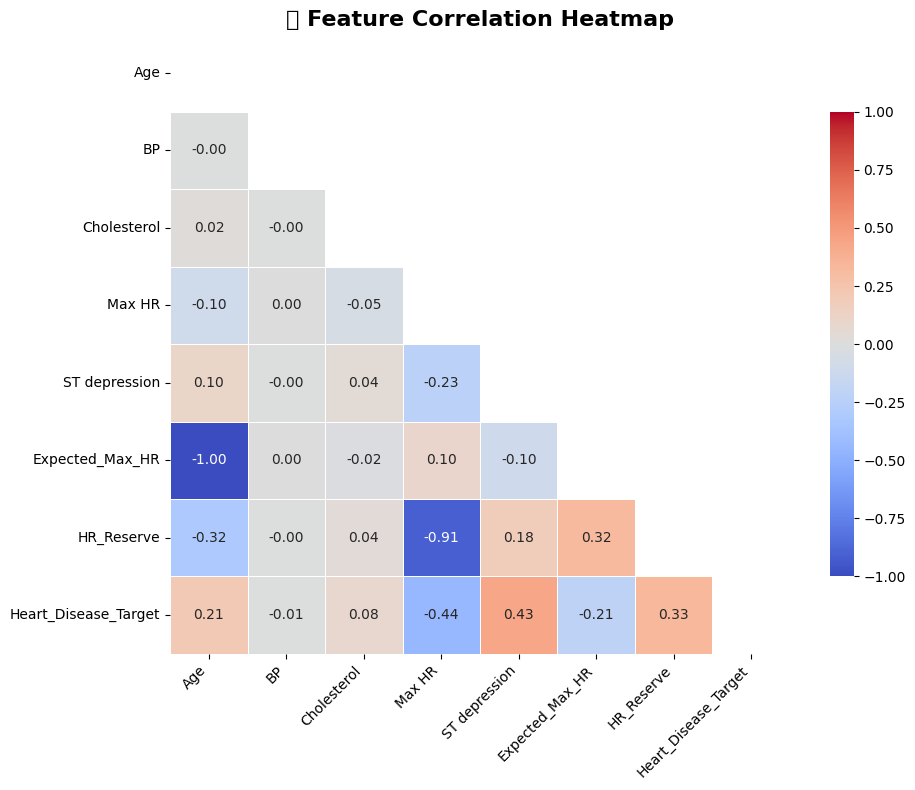

In [ ]:
# Select key numerical features and the target
corr_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Expected_Max_HR', 'HR_Reserve', 'Heart_Disease_Target']
corr_matrix = train_df[corr_cols].corr()

# Create a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
plt.title('🔍 Feature Correlation Heatmap', fontsize=16, color='black', weight='bold')

# Draw the heatmap using Seaborn
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# 1. Define the metrics we want to compare
radar_metrics = ['Age', 'BP', 'Cholesterol', 'ST depression']

# 2. Calculate the average values for both groups (Presence vs Absence)
agg_df = train_df.groupby('Heart Disease')[radar_metrics].mean().reset_index()

# 3. Scale the data using MinMaxScaler so they fit perfectly on the same radar plot
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(agg_df[radar_metrics])

# 4. Create the Interactive Radar Chart
fig = go.Figure()

# Add trace for "Absence" (Healthy)
fig.add_trace(go.Scatterpolar(
      r=scaled_values[0].tolist() + [scaled_values[0][0]], # Close the loop
      theta=radar_metrics + [radar_metrics[0]],
      fill='toself',
      name='Absence (Healthy)',
      line_color='#2ecc71'
))

# Add trace for "Presence" (Heart Disease)
fig.add_trace(go.Scatterpolar(
      r=scaled_values[1].tolist() + [scaled_values[1][0]], # Close the loop
      theta=radar_metrics + [radar_metrics[0]],
      fill='toself',
      name='Presence (Heart Disease)',
      line_color='#e74c3c'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(visible=True, range=[0, 1])
  ),
  showlegend=True,
  title='🕸️ Patient Profile Comparison: Healthy vs. Heart Disease',
  template='plotly_dark'
)

fig.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import lightgbm as lgb
import optuna

# 1. Apply Feature Engineering to Test Set
test_df['Expected_Max_HR'] = 220 - test_df['Age']
test_df['HR_Reserve'] = test_df['Expected_Max_HR'] - test_df['Max HR']
test_df['BP_Category'] = test_df['BP'].apply(categorize_bp)

# 2. Drop unnecessary columns (like ID)
X = train_df.drop(columns=['id', 'Heart Disease', 'Heart_Disease_Target'])
y = train_df['Heart_Disease_Target']
test_X = test_df.drop(columns=['id'])

# 3. One-Hot Encoding for Categorical Variables
# We align train and test sets to ensure they have the exact same dummy columns
X = pd.get_dummies(X, drop_first=True)
test_X = pd.get_dummies(test_X, drop_first=True)
X, test_X = X.align(test_X, join='left', axis=1, fill_value=0)

# 4. Train-Validation Split (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Preprocessing Completed! Training features shape: {X_train.shape}")

✅ Preprocessing Completed! Training features shape: (504000, 18)


In [ ]:
# OPTUNA HYPERPARAMETER TUNING
def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'verbose': -1,
        'random_state': 42
    }
    
    # Create LightGBM Dataset
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    # Train the model with early stopping
    gbm = lgb.train(
        param,
        dtrain,
        num_boost_round=500,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    # Predict on validation set
    preds = gbm.predict(X_val, num_iteration=gbm.best_iteration)
    auc = roc_auc_score(y_val, preds)
    return auc

# Create and run the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Set to 30 or 50 for a real run!

print("\n🏆 Best Trial Results:")
print(f"Best AUC: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-02-28 18:05:38,089] A new study created in memory with name: no-name-4de2a3b3-8a5b-4a4a-bcf4-65afdb0a0294
[I 2026-02-28 18:05:44,837] Trial 0 finished with value: 0.9558574730371938 and parameters: {'learning_rate': 0.17955152369504895, 'num_leaves': 26, 'max_depth': 11, 'feature_fraction': 0.8860716656301537, 'bagging_fraction': 0.7973800937888615, 'bagging_freq': 4, 'min_child_samples': 59}. Best is trial 0 with value: 0.9558574730371938.
[I 2026-02-28 18:06:04,388] Trial 1 finished with value: 0.9556126843034802 and parameters: {'learning_rate': 0.026117833948303946, 'num_leaves': 26, 'max_depth': 5, 'feature_fraction': 0.9797624557135919, 'bagging_fraction': 0.7050590682899025, 'bagging_freq': 4, 'min_child_samples': 25}. Best is trial 0 with value: 0.9558574730371938.
[I 2026-02-28 18:06:33,124] Trial 2 finished with value: 0.9558359562563429 and parameters: {'learning_rate': 0.02089813308983545, 'num_leaves': 60, 'max_depth': 12, 'feature_fraction': 0.5236848709637483, 'b


🏆 Best Trial Results:
Best AUC: 0.9559
Best Parameters:
    learning_rate: 0.10280394168331886
    num_leaves: 47
    max_depth: 12
    feature_fraction: 0.7223568058280699
    bagging_fraction: 0.8699632159310635
    bagging_freq: 2
    min_child_samples: 42


In [ ]:
# Train the Final Model using Best Parameters
best_params = study.best_params
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['verbose'] = -1
best_params['random_state'] = 42

dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

final_model = lgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

# Validation Predictions (Threshold = 0.5)
val_preds_prob = final_model.predict(X_val, num_iteration=final_model.best_iteration)
val_preds_class = (val_preds_prob > 0.5).astype(int)

print("\n📊 Classification Report on Validation Data:")
print(classification_report(y_val, val_preds_class, target_names=['Absence (0)', 'Presence (1)']))

Training until validation scores don't improve for 50 rounds
[100]	training's auc: 0.956119	valid_1's auc: 0.955639
[200]	training's auc: 0.957708	valid_1's auc: 0.955909
Early stopping, best iteration is:
[237]	training's auc: 0.958197	valid_1's auc: 0.955916

📊 Classification Report on Validation Data:
              precision    recall  f1-score   support

 Absence (0)       0.90      0.91      0.90     69509
Presence (1)       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



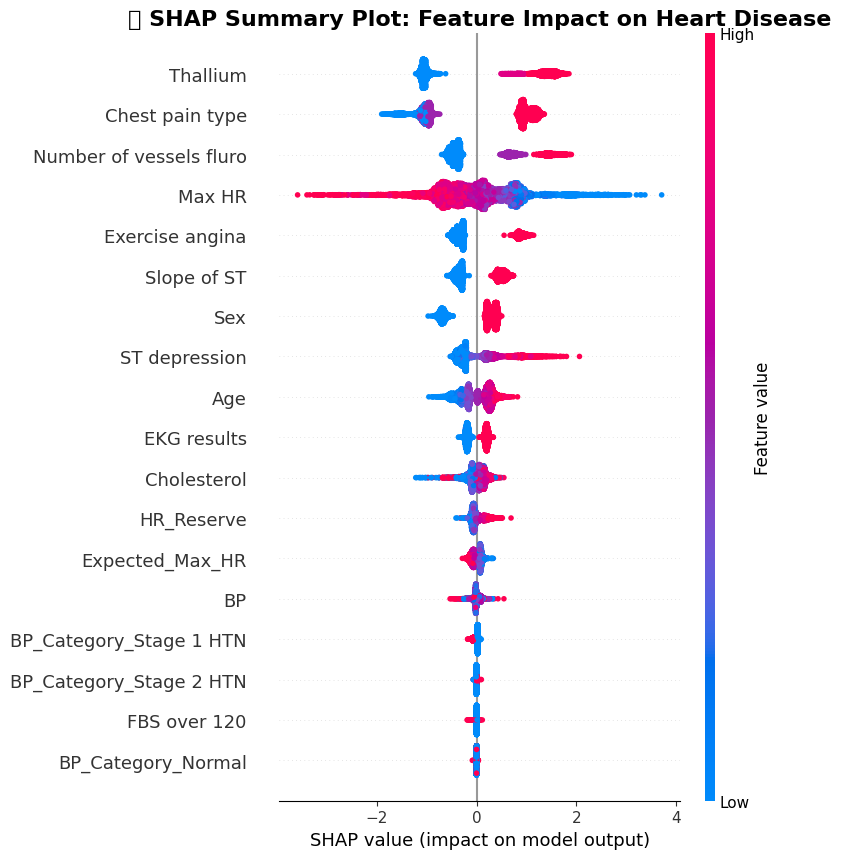

In [ ]:
import shap

# Initialize JavaScript visualizations in the notebook
shap.initjs()

# Create a Tree Explainer for our tuned LightGBM model
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for the validation set (using a sample to save time if needed, but 20% of 630k is fast enough for LightGBM)
# To avoid memory overload in Kaggle, let's explain a random sample of 10,000 patients
X_val_sample = X_val.sample(n=10000, random_state=42)
shap_values = explainer.shap_values(X_val_sample)

# LightGBM binary classification usually returns an array of SHAP values. 
# Sometimes it returns a list of length 2. We handle both:
shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

# 1. SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("🩺 SHAP Summary Plot: Feature Impact on Heart Disease", fontsize=16, weight='bold')
shap.summary_plot(shap_values_to_plot, X_val_sample, show=False)
plt.tight_layout()
plt.show()

In [ ]:

# FINAL PREDICTIONS ON THE TEST SET


# Predict probabilities on the unseen Test Set
test_preds_prob = final_model.predict(test_X, num_iteration=final_model.best_iteration)

# Convert probabilities back to original categories ('Presence' or 'Absence')
# Threshold is set at 0.5
test_preds_class = np.where(test_preds_prob > 0.5, 'Presence', 'Absence')

# Create the Submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'Heart Disease': test_preds_class
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

# Display the first few rows and a success message
print("🎉 SUCCESS: 'submission.csv' file has been generated!")
print("-" * 50)
print(submission.head().to_markdown(index=False))

🎉 SUCCESS: 'submission.csv' file has been generated!
--------------------------------------------------
|     id | Heart Disease   |
|-------:|:----------------|
| 630000 | Presence        |
| 630001 | Absence         |
| 630002 | Presence        |
| 630003 | Absence         |
| 630004 | Absence         |
